# Machine Learning for Quantitative Finance (Part 1)
### QuantSoc workshop · about 70 minutes · [quant-soc.com](https://quant-soc.com)

In about seventy minutes you will build a small machine learning strategy on twenty years of real stock prices, test it
honestly, and leave with a backtest of **your own** choices and a file you can run on a practice trading account.
A **backtest** is a replay of a strategy's trading rules on past prices, as if you had traded them, to see what
would have happened.

**Pipeline:** `prices → features → model → forecasts → portfolio → backtest → export`.
You set five knobs of your strategy in five short tasks. Each task is **copy and change**: a worked example sits
directly above it, and you change one, two or three numbers.

| Section | What happens | Minutes |
|---|---|---|
| 0. Setup | run the two setup cells while the talk starts | 0 to 6 |
| 1. The data | 40 large US companies, daily, 2000 to 2019 | 6 to 11 |
| 2. Features, the target and the no-peeking rule | where features come from, Tasks 1 and 2, and a leakage demo | 11 to 31 |
| 3. A baseline and a fair test | predict zero, split by time, Task 3 | 31 to 39 |
| 4. A real ML model | a random forest, Task 4, the decile plot | 39 to 48 |
| 5. Overfitting, live | a model that learns noise | 48 to 54 |
| 6. From forecasts to a portfolio | long and short, costs, Task 5 | 54 to 60 |
| 7. Your strategy's backtest | your five knobs, after costs, read honestly | 60 to 65 |
| 8. Export and paper trading | download your strategy, preview its orders | 65 to 71 |

> **Disclosure.** The prices are **real**: a snapshot of Yahoo Finance data downloaded with the `yfinance` package
> and saved with the workshop. The universe is **survivorship-biased**: 40 large companies that still trade today,
> so every company that failed or was bought between 2000 and 2019 is missing. That makes buying stocks look
> better than it was, and betting against them look worse. This notebook is for **teaching only**. Nothing in it
> is investment advice, and the strategy it builds has no reliable **edge** (a small, repeatable advantage)
> after trading costs.

**How the tasks work.** Each task cell starts as a copy of the worked example above it, with `# <- change this`
on the line to edit. Run it: the tracker `ex` prints `[ok]` or one plain sentence saying what to change.
`ex.hint(n)` shows a hint (run it again for the next one), `ex.show_solution(n)` prints the reference answer,
and `ex.use_reference(n)` continues with the reference answer. A reference answer is always labelled as such,
never swapped in silently.

**Two ways to run this notebook.** Google Colab (recommended, nothing to install), or Jupyter on your own computer
(see `README.md`). Both use the same cells.

## 0. Setup

Run the next two cells now, while the talk starts. The first one copies the workshop's files into this runtime
(a few seconds on Colab; instant on your own computer). The second one loads the code, checks the versions and
creates `ex`, the task tracker, and `my_strategy`, the strategy whose knobs you will set.

In [1]:
# @title Setup (run once; safe to run again)
OWNER, REPO, REVISION = "michaelbolebrukh", "quantsoc-ml-for-quant-finance", "v1.0.0"   # pinned workshop release

import io, os, shutil, sys, urllib.request, zipfile
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = Path("/kaggle/working").exists()
FILES = ["quantsoc_ml", "data", "docs", "run_paper.py", "requirements.txt", ".env.example", "fetch_data.py"]


def fetch_release(root: Path):
    """Copy the pinned release into `root` (Colab or Kaggle). Never touches root/workspace (your own files)."""
    marker, wanted = root / ".release", f"{OWNER}/{REPO}@{REVISION}"
    if marker.exists() and marker.read_text().strip() == wanted:
        print("Workshop files are already here.")
        return
    src = None
    if IN_KAGGLE:                                          # a Kaggle dataset of the repository, if attached
        hit = next(Path("/kaggle/input").rglob("quantsoc_ml/__init__.py"), None)
        src = hit.parent.parent if hit else None
    if src is None:
        url = f"https://github.com/{OWNER}/{REPO}/archive/{REVISION}.zip"
        print("Downloading the workshop files from", url)
        with zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url, timeout=60).read())) as zf:
            tmp = root.parent / "_workshop_src"
            shutil.rmtree(tmp, ignore_errors=True)
            zf.extractall(tmp)
        src = tmp / zf.namelist()[0].split("/")[0]
    root.mkdir(parents=True, exist_ok=True)
    for item in FILES:
        s, d = src / item, root / item
        if s.is_dir():
            shutil.rmtree(d, ignore_errors=True)
            shutil.copytree(s, d)
        elif s.exists():
            shutil.copy(s, d)
    marker.write_text(wanted)
    print("Done.")


if IN_COLAB:
    ROOT = Path("/content/workshop"); fetch_release(ROOT)
elif IN_KAGGLE:
    ROOT = Path("/kaggle/working/workshop"); fetch_release(ROOT)
else:                                                      # your own computer: find the workshop folder
    here = Path.cwd().resolve()
    ROOT = next((p for p in [here, *here.parents]
                 if (p / "quantsoc_ml" / "__init__.py").exists() and (p / "data").is_dir()), None)
    if ROOT is None:
        raise SystemExit("Cannot find the workshop folder (it holds quantsoc_ml/ and data/). "
                         "Start Jupyter from inside the unzipped workshop folder.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))                          # first, so the next cell can import the package

WORK = Path(os.environ.get("QSW_WORK_DIR") or ROOT / "workspace")   # your exported strategy goes here
try:
    WORK.mkdir(parents=True, exist_ok=True)
    (WORK / ".write_test").write_text("ok"); (WORK / ".write_test").unlink()
except OSError as e:                                       # not a folder, or not writable: use a temporary one
    import tempfile
    print(f"[!] Cannot save your files in {WORK} ({e.strerror or type(e).__name__}).\n"
          "    To choose another folder, set QSW_WORK_DIR to a folder you can write to, for example\n"
          "    os.environ['QSW_WORK_DIR'] = str(Path.home() / 'workshop_files'), and run this cell again.")
    WORK = Path(tempfile.gettempdir()) / "quantsoc_workspace"
    WORK.mkdir(parents=True, exist_ok=True)
    print(f"    For now your files go to a temporary folder: {WORK}")
print(f"workshop folder: {ROOT}\nyour files:      {WORK}\nrunning in:      "
      f"{'Google Colab' if IN_COLAB else 'Kaggle' if IN_KAGGLE else 'local Jupyter'}")

workshop folder: /Users/michaelbolebrukh/Downloads/quantsoc-ml-for-quant-finance
your files:      /Users/michaelbolebrukh/Downloads/quantsoc-ml-for-quant-finance/workspace
running in:      local Jupyter


In [2]:
# Imports, environment check, the task tracker and your strategy (about 2 seconds)
%matplotlib inline
import warnings; warnings.filterwarnings("ignore", category=FutureWarning)
from dataclasses import replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from quantsoc_ml import viz
from quantsoc_ml.data import load_prices, to_wide, daily_returns
from quantsoc_ml.features import past_return, rolling_vol, build_features, rank_normalise, forward_return, make_dataset, leaky_feature
from quantsoc_ml.splits import time_split, split_report, random_split
from quantsoc_ml.models import fit_linear, fit_forest, xy, predict_panel
from quantsoc_ml.evaluate import decile_table, noise_experiment
from quantsoc_ml.portfolio import weights_from_forecasts
from quantsoc_ml.backtest import run_benchmark
from quantsoc_ml.export import export_bundle
from quantsoc_ml.exercises import ExerciseTracker
from quantsoc_ml.notebook_support import (environment_report, setup_ipython, runtime_loss_notice, reading_box, timed,
    pct, quarter_sample, make_forest, feature_ic_table, score_table, model_scores, stats_view, equity_figure,
    drawdown_figure, cost_per_year, run_backtest, backtests_run, backtest_checklist, export_checkpoint,
    run_paper_preview, make_deck_figures)        # run_backtest here is the package's, counted for the checklist

setup_ipython()                       # short messages instead of long error reports
ex = ExerciseTracker()                # checks, hints and labelled reference answers for the five tasks
my_strategy = ex.my_strategy          # YOUR strategy: the five tasks set its knobs; a knob you do not set stays the reference
my_strategy.rank_features = True      # features are ranked across the 40 stocks each day (section 2 explains why)
pd.set_option("display.width", 140); pd.set_option("display.max_columns", 20)
display(environment_report())
if IN_COLAB or IN_KAGGLE:
    runtime_loss_notice()

,version
component,
python,3.12.14
numpy,2.5.3
pandas,3.0.6
scikit-learn,1.9.1
matplotlib,3.11.2
CPU cores,12
runtime,local Jupyter


In [3]:
display(reading_box("lopez_de_prado_2018_jpm",
    "most machine learning in finance fails for a few repeatable reasons; today we meet two of them: "
    "leakage (future information sneaking into a model's inputs, section 2) and backtest overfitting "
    "(trying settings until a strategy fits the past by luck, section 5)."))

## 1. The data

In [4]:
display(reading_box("afml", "Chapter 2: raw market data needs care before any model sees it. We use one clean daily "
                    "price per stock, adjusted for stock splits and dividends (both explained just below)."))

Each row of the price file is **one company on one trading day**. A **stock** is a share in a company. A
**trading day** is a day the US stock market was open (about 252 a year). We use the **adjusted close**
(`adj_close`): the closing price, corrected so that a stock split or a dividend payment does not look like a
sudden fall. In a **stock split** each share becomes several cheaper shares, so the price drops with no loss to
the owner. A **dividend** is cash a company pays its shareholders; the price falls by about that amount on the
day the payment is fixed.

We never model prices directly. We model **returns**: how much the price moved, as a fraction.
`return = price today / price yesterday - 1`, so `0.01` means the stock rose 1%.

🔮 **Predict:** over twenty years, did all 40 companies grow? Roughly how much does a typical stock move on a typical day: 0.1%, 1% or 10%?

201,200 rows = 40 stocks x 5,030 trading days, 2000-01-03 to 2019-12-30
a typical day moves a stock by about 0.85% (median size of a daily return)


,date,symbol,open,high,low,close,adj_close,volume
0,2000-01-03,AAPL,0.936384,1.004464,0.907924,0.999442,0.837002,535796800
1,2000-01-03,AMGN,70.000000,70.000000,62.875000,62.937500,42.005672,22914900
2,2000-01-03,AMZN,4.075000,4.478125,3.952344,4.468750,4.468750,322352000


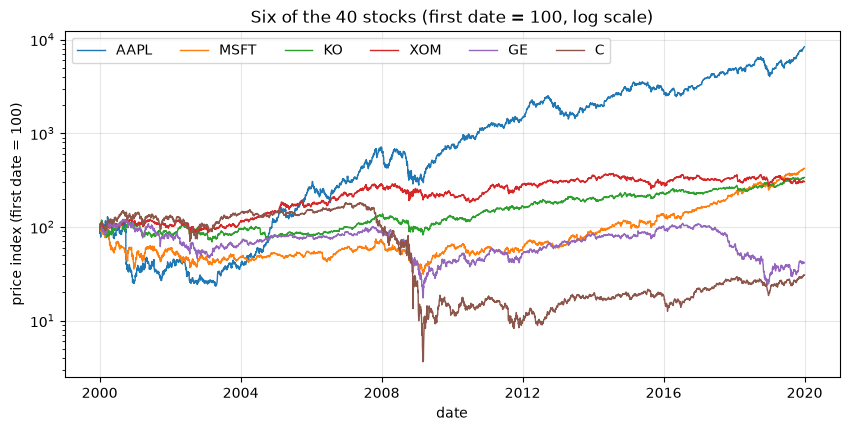

In [5]:
long = load_prices(ROOT / "data" / "prices.csv.gz")    # one row per (date, symbol)
prices = to_wide(long, "adj_close")                     # dates down, the 40 symbols across
volume = to_wide(long, "volume")                        # number of shares traded each day
returns = daily_returns(prices)                         # daily return of every stock
print(f"{len(long):,} rows = {prices.shape[1]} stocks x {prices.shape[0]:,} trading days, "
      f"{prices.index[0].date()} to {prices.index[-1].date()}")
print(f"a typical day moves a stock by about {returns.stack().abs().median():.2%} (median size of a daily return)")
display(long.head(3))
ex.set_context(1, prices=prices)
ex.set_context(2, prices=prices, returns=returns, volume=volume)
viz.price_panel(prices, ["AAPL", "MSFT", "KO", "XOM", "GE", "C"], title="Six of the 40 stocks");

**Reading the result.** Each line is one company, rescaled to start at 100 so they can be compared. The scale is
logarithmic, so equal steps up mean equal percentage gains. The paths differ hugely. 38 of the 40 stocks ended
higher (Apple about 84 times higher). GE and C (Citigroup) ended below where they started, after deep falls in
2008 and, for GE, again in 2018. A typical day moves a stock by under 1%, so a 5-day move is usually a few
percent.

**Where the data came from** (the full data card is `data/DATA_CARD.md`). Yahoo Finance, downloaded once with
`yfinance` and saved, so nothing here depends on a live download. The stocks are 40 large US companies (large
caps) from the S&P 100, an index of 100 of the biggest US companies. The data is daily, January 2000 to
December 2019. **Survivorship bias:** we kept only companies that still trade today. An investor in 2000 could
not have known which companies would survive. So in this notebook buying stocks (long positions) looks better
than it really was, and betting against them (short positions, section 6) looks worse. Section 6 comes back to
this.

## 2. Features, the target and the no-peeking rule

In [6]:
display(reading_box(["jegadeesh_titman_1993", "jegadeesh_1990", "kaufman_2012"],
    "past winners kept winning over 3 to 12 months (momentum), last month's winners tended to fall back "
    "(reversal), and leakage, future information sneaking into the inputs, makes a model look far better than it is."))

A **feature** is a number computed from the past that might help predict the future, for example "how much did
this stock rise over the last month?". The **target** is the future number we want to predict. Ours is the
return over the **next 5 trading days**: `price 5 days later / price today - 1`.

**The no-peeking rule** (the one rule this whole workshop teaches): a feature for day `t` may only use
information up to and including day `t`. Only the target looks forward. We pretend we trade at the close of day
`t`; a real system would trade at the next morning's open, so this is a simplification.

**Where features come from.** Choosing and building features is most of the work in quantitative research. Researchers
have tested hundreds of them. Most fall into the families below. This notebook uses only the first three, because they
need nothing but daily prices and volumes, which are free.

| Family | Examples | Data you need | In this notebook? |
|---|---|---|---|
| Price and technical | momentum, reversal, distance from the 52-week high | daily prices | yes |
| Volatility and risk | realised volatility, beta, idiosyncratic volatility | daily prices | yes (volatility) |
| Volume and liquidity | volume surprise, turnover, bid-ask spread, Amihud illiquidity | volumes, quotes | yes (volume surprise) |
| Fundamentals | book-to-market, earnings yield, profitability, accruals, asset growth | company accounts | no |
| Analysts and events | earnings surprise, forecast revisions, earnings dates | analyst and event databases | no |
| Alternative data | news and filings text, web traffic, card spending, satellite images | specialist vendors | no |
| Order book | order imbalance, queue depth | tick-by-tick exchange data | no |
| Macro and cross-asset | interest rates, credit spreads, the VIX, currency moves | market and economic data | no |

One warning for later: company accounts get **restated** (corrected after publication). A backtest must use the
numbers as they were first published, called **point-in-time** data, or it leaks the future, which is the
problem section 2 ends with.

**Momentum** means "what went up keeps going up". It is measured by the past return over some number of days,
called the **lookback**. Jegadeesh and Titman found momentum over 3 to 12 months; at one month and shorter,
Jegadeesh found the opposite, reversal.

**Worked example: a momentum feature with a 5-day lookback.**

In [7]:
lookback = 5                                       # the worked example: 5 trading days, about one week
example_momentum = past_return(prices, lookback)   # return over the last `lookback` days, every stock, every day
example_momentum.iloc[-3:, :5]                     # the last three days for the first five stocks

,AAPL,AMGN,AMZN,AXP,BA
date,,,,,
2019-12-26,0.036355,-0.000165,0.047499,0.009255,-0.002298
2019-12-27,0.034926,-0.001282,0.043252,0.002884,-0.010075
2019-12-30,0.043230,-0.011478,0.033804,-0.011688,-0.004878


### ✏️ Task 1: your momentum lookback
Copy and change: pick your own lookback, any whole number of trading days from 2 to 252, other than 5.
21 is about a month, 63 about three months, 252 about a year.

In [8]:
lookback = 5                                       # <- change this: your lookback in trading days (2 to 252)
my_momentum = past_return(prices, lookback)
ex.check(1, my_momentum, lookback)

Task 1: Momentum lookback
  [x] Not yet: 5 is the worked example's lookback. Choose your own, for example 21 (about one month).
      Allowed: any lookback from 2 to 252 trading days, other than the worked example's 5.
      Help: ex.hint(1)   Answer: ex.show_solution(1)   Continue anyway: ex.use_reference(1)
  QSW_AUTO_REFERENCE=1: continuing with the reference answer (labelled).
  [ref] Task 1 (Momentum lookback): using the workshop REFERENCE answer. This is recorded, and labelled in your export.


**Volatility** is how much a price swings. We measure it as the **standard deviation** of the daily returns over
a recent **window** of days. That is roughly the typical size of a daily move away from the average: a bigger
number means a jumpier stock. Volatility is the strategy's extra feature.

**Worked example: volatility over a 21-day window.**

In [9]:
window = 21                                        # the worked example: 21 trading days, about one month
example_vol = rolling_vol(returns, window)         # how much each stock's daily return swung over the last `window` days
example_vol.iloc[-3:, :5]

,AAPL,AMGN,AMZN,AXP,BA
date,,,,,
2019-12-26,0.011122,0.006842,0.012140,0.010318,0.016132
2019-12-27,0.010839,0.006859,0.011905,0.010166,0.016125
2019-12-30,0.010650,0.007011,0.012058,0.010346,0.016047


### ✏️ Task 2: your extra feature
Copy and change: pick your own volatility window from 2 to 252, other than 21 (21 is already one of the features).

In [10]:
window = 21                                        # <- change this: your window in trading days (2 to 252)
my_extra = rolling_vol(returns, window)
ex.check(2, my_extra, window)

Task 2: Extra feature
  [x] Not yet: 21 is the worked example's window. Choose your own, for example 63 (about three months).
      Allowed: any volatility window from 2 to 252 other than the worked example's 21, or another feature name (ret_N or vol_N with N from 2 to 252, volume_z or hi52) that is not already a feature.
      Help: ex.hint(2)   Answer: ex.show_solution(2)   Continue anyway: ex.use_reference(2)
  QSW_AUTO_REFERENCE=1: continuing with the reference answer (labelled).
  [ref] Task 2 (Extra feature): using the workshop REFERENCE answer. This is recorded, and labelled in your export.


**All the features.** Your two choices go into the eight features the model will use. Four are past returns:
over 1 day, 5 days, your lookback and 63 days. Two are volatilities: over 21 days and over your window. `volume_z`
says how unusual today's trading volume is, and `hi52` how far the price sits below its highest point of the last
year. All of them use only the past.

In [11]:
ex.uses(1, 2)                                      # prints a [ref] line if Task 1 or 2 is not yours yet
names = my_strategy.feature_names                  # the eight features, with your two choices in their slots
feats = build_features(prices, volume, names=names)
print("features:", names)
feats.xs(pd.Timestamp("2019-12-30"), level="date").head(4)     # one day, the first four stocks

  [ref] Task 1 (Momentum lookback) is not yours yet: momentum_lookback = 21 is the workshop's reference. Finish Task 1 above and run this cell again to use your own.
  [ref] Task 2 (Extra feature) is not yours yet: extra_feature = vol_63 is the workshop's reference. Finish Task 2 above and run this cell again to use your own.
features: ['ret_1', 'ret_5', 'ret_21', 'ret_63', 'vol_21', 'vol_63', 'volume_z', 'hi52']


,ret_1,ret_5,ret_21,ret_63,vol_21,vol_63,volume_z,hi52
symbol,,,,,,,,
AAPL,0.005935,0.043230,0.088411,0.305511,0.010650,0.011385,1.168238,0.000000
AMGN,-0.005217,-0.011478,0.024431,0.249892,0.007011,0.008702,-0.861004,-0.012048
AMZN,-0.012253,0.033804,0.015606,0.063932,0.012058,0.010083,0.554993,-0.086146
AXP,-0.007109,-0.011688,0.032993,0.054915,0.010346,0.010683,-0.509432,-0.029514


**Ranking the features.** We rank each feature across the 40 stocks each day, so the model sees "this stock is in
the top 10% for momentum today" rather than a raw number. This is what Gu, Kelly and Xiu do. A ranked value runs
from about -0.5 (lowest of the 40 that day) to about +0.5 (highest), with 0 in the middle.

In [12]:
ranked = rank_normalise(feats)                     # each feature becomes its rank among the 40 stocks that day
ranked.xs(pd.Timestamp("2019-12-30"), level="date").head(4)

,ret_1,ret_5,ret_21,ret_63,vol_21,vol_63,volume_z,hi52
symbol,,,,,,,,
AAPL,0.4875,0.4875,0.4625,0.4625,0.2125,0.0375,0.4875,0.4875
AMGN,0.0875,-0.3125,0.0625,0.4125,-0.1875,-0.3875,-0.1125,0.1125
AMZN,-0.3625,0.4625,-0.0875,-0.0625,0.3625,-0.3125,0.4625,-0.2625
AXP,-0.1125,-0.3375,0.1375,-0.0875,0.1625,-0.1875,0.1375,-0.0875


**The target, and the dataset.** One row per stock per day: the ranked features known at the close of day `t`,
and the return from `t` to `t + 5`. Rows without a full set of features (the first year) or without a target
(the last 5 days) are dropped. The check below recomputes one target by hand.

In [13]:
target = forward_return(prices, 5)                 # the ONLY forward-looking number: return over the next 5 trading days
ds = make_dataset(ranked, target)
ex.set_context(3, ds=ds)
day, later = prices.index[-30], prices.index[-25]
print(f"{len(ds):,} rows, {ds.index.get_level_values('date').nunique():,} days")
print(f"AAPL target on {day.date()}: {ds.loc[(day, 'AAPL'), 'target']:+.4f}   by hand: "
      f"{prices.loc[later, 'AAPL'] / prices.loc[day, 'AAPL'] - 1:+.4f} (price on {later.date()} / price on {day.date()} - 1)")

190,960 rows, 4,774 days
AAPL target on 2019-11-15: -0.0150   by hand: -0.0150 (price on 2019-11-22 / price on 2019-11-15 - 1)


### Leakage, live
Now we break the no-peeking rule on purpose. `LEAKY_ret_next` is **tomorrow's** return, dressed up as a feature.
We score each feature by its **correlation** with the target: a number from -1 to +1 that says how well
"higher feature" lines up with "higher return". Here it is measured across the 40 stocks each day, then averaged
over the days.

🔮 **Predict:** the honest features score a few hundredths at most. What will the leaky one score?

In [14]:
leaky = leaky_feature(prices)                      # tomorrow's return: breaks the no-peeking rule ON PURPOSE
with_leak = ds.join(leaky, how="left")
display(feature_ic_table(with_leak, names + ["LEAKY_ret_next"]))
del with_leak, leaky                               # and now it is gone: nothing below uses it

,correlation with the target (mean per day),days with a positive correlation
feature,,
ret_1,-0.014,48%
ret_5,-0.021,47%
ret_21,-0.010,48%
ret_63,-0.003,51%
vol_21,+0.008,52%
vol_63,+0.010,52%
volume_z,+0.011,52%
hi52,-0.004,51%
LEAKY_ret_next,+0.396,96%


**Reading the result.** The honest features have correlations of about 0.02 or less, some positive and some
negative. The leaky feature scores about 0.4 and points the right way on about 96% of days. That is too good to be
true, and it is: tomorrow's return is part of the 5-day target, and you can never know it today. A number that
looks this good is a reason to look for a leak, not a reason to celebrate. The leaky column was deleted, and
nothing below uses it.

## 3. A baseline and a fair test

In [15]:
display(reading_box(["afml", "gu_kelly_xiu_2020"],
    "Chapter 7, section 7.2: shuffled cross-validation (scoring a model on several held-out slices of the data "
    "in turn) leaks on financial data, so split by time. Gu, Kelly and Xiu: "
    "even good models explain well under 1% of the ups and downs of returns on data they have not seen."))

A **model** is a rule, learned from past examples, that turns features into a **forecast** (its guess of the
target). Before any machine learning we need something to beat. The **baseline** is the laziest forecast
possible: **predict zero**, "nothing will happen", for every stock on every day.

We score a forecast by its **mean squared error** (MSE): the average of (forecast - what happened) squared. Smaller
is better. From it we compute **R squared vs zero**: `1 - MSE of the model / MSE of predicting zero`. Above 0 means
the model beats the baseline; a model that predicts zero scores exactly 0.

🔮 **Predict:** how far is a typical 5-day return from zero: about 0.4%, 4% or 40%?

In [16]:
mse_zero = float((ds["target"] ** 2).mean())        # predicting zero: the error is the whole target
print(f"MSE of predicting zero: {mse_zero:.6f}, so a typical 5-day return is about {mse_zero ** 0.5:.1%} away from zero")
print(f"average 5-day return: {ds['target'].mean():+.2%}   (shares rose on average, slowly)")

MSE of predicting zero: 0.001723, so a typical 5-day return is about 4.2% away from zero
average 5-day return: +0.25%   (shares rose on average, slowly)


**Reading the result.** A typical 5-day move is about 4%, while the average move is only about +0.25%. Returns
are mostly noise around a small upward drift, which is why "nothing happens" is a tough opponent.

**A fair test.** **Training** means letting the model learn from examples; the **test** is a later stretch of data
the model never saw, used once to score it. In most machine learning courses rows are shuffled at random into
training and test. In finance that leaks: neighbouring days share 4 of their 5 target days, so a shuffled test day
almost always has a near copy in the training data. So we **split by time**: train on the past, then leave a gap
of at least 5 trading days (the **embargo**, so no training target overlaps the test), then test on what follows.

**Worked example: train up to the end of 2012, test from 10 January 2013.**

In [17]:
train_end, test_start = "2012-12-31", "2013-01-10"            # the worked example's two dates
example_train, example_test = time_split(ds, train_end, test_start)
split_report(example_train, example_test)

,first_date,last_date,trading_days,rows,calendar_days_since_train_end
split,,,,,
train,2000-12-29,2012-12-31,3018,120720,NaN
test,2013-01-10,2019-12-20,1750,70000,10.0


### ✏️ Task 3: your split dates
Copy and change: `train_end` any day from 2008-12-31 to 2016-12-31; `test_start` at least 5 trading days later and
before 2018. A later `train_end` gives the model more to learn from but leaves a shorter test.

In [18]:
train_end, test_start = "2012-12-31", "2013-01-10"            # <- change this: your two dates, "YYYY-MM-DD"
train, test = time_split(ds, train_end, test_start)
ex.check(3, (train, test), train_end, test_start)

Task 3: Split dates
  [x] Not yet: these are the worked example's two dates. Change at least one of them on the line marked '# <- change this', for example train_end "2014-12-31" and test_start "2015-01-12".
      Allowed: train_end from 2008-12-31 to 2016-12-31; test_start at least 5 trading days later and before 2018 (not both of the worked example's dates).
      Help: ex.hint(3)   Answer: ex.show_solution(3)   Continue anyway: ex.use_reference(3)
  QSW_AUTO_REFERENCE=1: continuing with the reference answer (labelled).
  [ref] Task 3 (Split dates): using the workshop REFERENCE answer. This is recorded, and labelled in your export.


  [ref] Task 3 (Split dates) uses the workshop's reference answer, so the cells below do too. Finish Task 3 above and run this cell again to use your own.


,first_date,last_date,trading_days,rows,calendar_days_since_train_end
split,,,,,
train,2000-12-29,2014-12-31,3522,140880,NaN
test,2015-01-12,2019-12-20,1246,49840,12.0


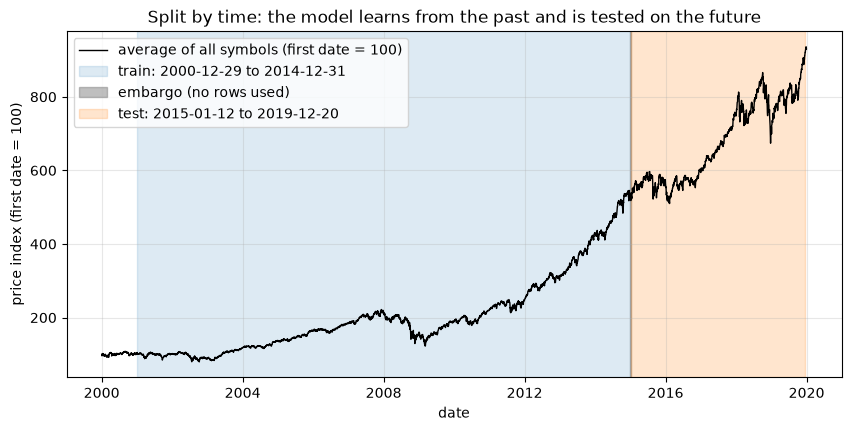

In [19]:
train, test = ex.result(3)                                    # your split (or the labelled reference)
display(split_report(train, test))
viz.split_timeline(train, test, prices);

### Why never at random: the same model, two splits
We train the same model twice: once on your time split, and once on a shuffled split of the same rows. Each is
scored on its own test set. The model is a **random forest**, explained properly in section 4; here it is just "a
standard machine learning model". To keep this under 10 seconds each model learns from a quarter of the training
rows. Two new scores. **IC per day** (information coefficient) is the correlation between forecasts and outcomes
across the 40 stocks on one day, averaged over days. **Top minus bottom decile** is how much more the 10% highest
forecasts earned over 5 days than the 10% lowest.

🔮 **Predict:** which split will make the model look better, and by how much?

In [20]:
honest = fit_forest(*xy(quarter_sample(train)), n_estimators=100, max_depth=6)       # learns from the past only
shuffled_train, shuffled_test = random_split(ds, test_size=0.25, seed=0)             # WRONG ON PURPOSE
shuffled = fit_forest(*xy(quarter_sample(shuffled_train)), n_estimators=100, max_depth=6)
model_scores({"time split (honest)": (honest, test), "random split (leaky)": (shuffled, shuffled_test)})

,r2 vs zero,"IC, all rows pooled",IC per day (mean),days with IC > 0,top minus bottom decile (5 days)
forecast,,,,,
time split (honest),+0.11%,+0.013,+0.0123,53.1%,+0.10%
random split (leaky),+0.56%,+0.024,+0.0201,52.3%,+0.61%


**Reading the result.** With the workshop's dates we measured, time split against random split: R squared +0.11%
against +0.56%, IC per day +0.012 against +0.020, and a top minus bottom decile spread of +0.10% against +0.61%.
On the shuffled split the same model's R squared is five times higher and its decile spread six times wider.
None of that extra skill is real.
It comes from near copies of test days sitting in the training data. If you chose other dates your numbers differ,
but the random split nearly always flatters. From here on we only use your time split.

## 4. A real ML model

In [21]:
display(reading_box(["breiman_2001", "krauss_2017"],
    "a random forest averages many decision trees, each grown on a random sample of the data; Krauss, Do and Huck "
    "ranked S&P 500 stocks by such forecasts and traded the top against the bottom, as we will."))

A **decision tree** asks a yes or no question about a feature ("is this stock in the top half for 5-day return
today?"), then another, and so on. Each path ends in a **leaf**, whose forecast is the average target of the
training rows that ended up there. `max_depth` is how many questions a tree may ask in a row: a deeper tree fits
more detail, including noise. Our trees also need at least 50 training rows in every leaf, a brake against
memorising single days.

A **random forest** grows many trees (`n_estimators`), each on a random sample of the rows, and averages their
forecasts. One tree is jumpy; the average of many is steadier.

For speed, the forest in this section learns from a **quarter** of the training rows: the same share of stocks
from every date, so no year is left out. Section 7 fits your final forest on the same quarter, so the two
sections agree.

In [22]:
sample = quarter_sample(train)                     # 25% of the training rows, from every date
X_quarter, y_quarter = xy(sample)                  # X: the features, y: the target
X_test, y_test = xy(test)
ex.set_context(4, X_quarter=X_quarter, y_quarter=y_quarter)
print(f"learning from {len(sample):,} rows; testing on {len(test):,} rows")

learning from 35,220 rows; testing on 49,840 rows


**Worked example: a forest of 100 trees, each at most 4 questions deep** (about 1 second).

In [23]:
n_estimators, max_depth = 100, 4                   # the worked example: 100 trees, depth 4
example_forest = make_forest(X_quarter, y_quarter, n_estimators, max_depth)   # checks the two numbers, then fits
print(f"fitted {len(example_forest.estimators_)} trees")

fitted 100 trees


### ✏️ Task 4: your forest
Copy and change: `n_estimators` from 20 to 500, `max_depth` from 2 to 12. A number outside those ranges is refused
before any fitting starts. Measured on 4 cores: 200 trees of depth 6 take about 3 seconds; 500 trees of depth 12
about 9 seconds. Colab's free tier has 2 cores, so allow up to twice that.

In [24]:
n_estimators, max_depth = 100, 4                   # <- change this: trees (20 to 500) and depth (2 to 12)
my_forest = make_forest(X_quarter, y_quarter, n_estimators, max_depth)
ex.check(4, my_forest, n_estimators, max_depth)

Task 4: Forest size
  [x] Not yet: 100 trees of depth 4 is the worked example. Change at least one of the two numbers, for example 200 trees of depth 6.
      Allowed: n_estimators from 20 to 500 and max_depth from 2 to 12 (not both of the worked example's numbers).
      Help: ex.hint(4)   Answer: ex.show_solution(4)   Continue anyway: ex.use_reference(4)
  QSW_AUTO_REFERENCE=1: continuing with the reference answer (labelled).


  [ref] Task 4 (Forest size): using the workshop REFERENCE answer. This is recorded, and labelled in your export.


**Your forest against the baselines, on the test period.** Two baselines this time: predicting zero, and
predicting a constant, the average 5-day return of the training period. A **linear model** (a weighted sum of the
features) learns from the same rows.

🔮 **Predict:** will your forest beat predicting zero? Will it beat the constant?

In [25]:
forest = ex.result(4)                              # your forest (or the labelled reference)
linear = fit_linear(X_quarter, y_quarter)
forecasts = {"predict zero": np.zeros(len(test)), "constant (training average)": np.full(len(test), y_quarter.mean()),
             "linear model": linear.predict(X_test), "your forest": forest.predict(X_test)}
score_table(forecasts, test)

  [ref] Task 4 (Forest size) uses the workshop's reference answer, so the cells below do too. Finish Task 4 above and run this cell again to use your own.


,r2 vs zero,"IC, all rows pooled",IC per day (mean),days with IC > 0
forecast,,,,
predict zero,+0.00%,n/a,n/a,n/a
constant (training average),+0.73%,n/a,n/a,n/a
linear model,+0.45%,+0.008,+0.0100,51.6%
your forest,+0.09%,+0.011,+0.0110,52.5%


**Reading the result.** With the reference forest (200 trees, depth 6) we measured R squared +0.09% against
+0.73% for the constant: on squared error the forest does **not** beat "shares rise on average". Its IC per day is
small and positive (about +0.01), positive on slightly more days than not. That is as much edge as these features
give: a slight tendency, far smaller than the noise, as Gu, Kelly and Xiu warn. And five years of test data are
too few to prove that even this slight tendency is real rather than luck. We leave out
the hit rate (the share of forecasts with the right sign) on purpose: the forest predicts a rise for nearly every
stock, so its hit rate only counts how often shares rose.

### The decile plot
Sort every test forecast from lowest to highest, cut them into ten equal groups called **deciles**, and plot the
average 5-day return that really followed in each group. If the model's ranking carries information, the bars
rise from left to right.

🔮 **Predict:** will the ten bars climb neatly, or wobble?

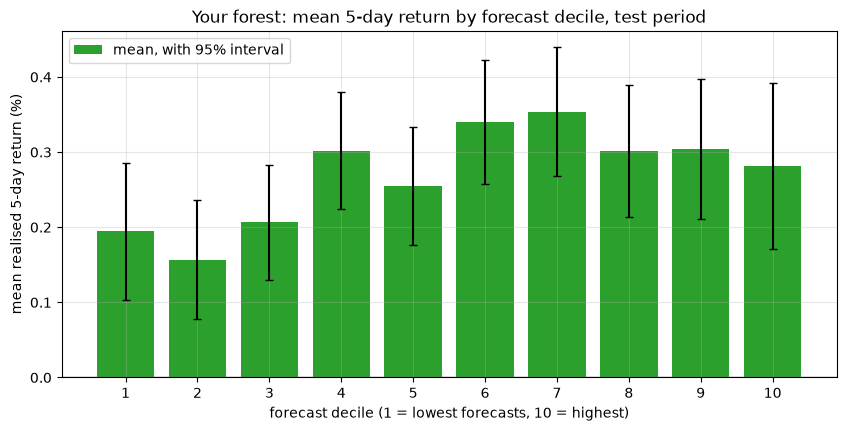

In [26]:
viz.decile_bar(decile_table(forest.predict(X_test), y_test), title="Your forest: mean 5-day return by forecast decile, test period");

**Reading the result.** The black lines are 95% intervals: a range drawn so that, if the test could be repeated
many times, it would hold the true average about 95 times in 100. Where two bars' intervals overlap, the
difference between them could easily be luck. With the reference forest (200 trees, depth 6) we measured the bottom two
deciles earning about 0.18% per 5 days and the top two about 0.29%, a difference of about 0.1%. But the bars do not
climb neatly: deciles 6 and 7 are the highest, and most neighbouring bars sit inside each other's intervals. So the
ranking carries a little information, not a staircase. Every bar is above zero because the market rose over the
test years; a long/short portfolio (section 6) cares only about the difference between bars.

## 5. Overfitting, live

In [27]:
display(reading_box("bailey_2014",
    "try enough strategies and one will look excellent in a backtest by luck alone; the more you try, the better "
    "the best-looking one appears, with zero real skill."))

**Overfitting** is when a model memorises its training data, noise included, instead of learning something that
lasts. Its training score goes up, and its test score does not.

The live experiment: we take the brakes off the forest (no depth limit, leaves of only 5 rows, 50 trees, 20,000
training rows). Then we fit it twice: on the real features, and on the real features plus **30 columns of pure
random numbers**, which by construction contain no information at all. The next cell is the slow one: about 15
seconds here (measured 11 to 16 s on 4 cores), up to twice that on Colab.

🔮 **Predict:** when we add the 30 noise columns, does the training score go up or down? And the test score?

[time] noise experiment: 6.5 s


,R squared on training rows,R squared on the test
real features,+48.35%,-7.46%
real + 30 noise columns,+59.82%,-4.14%


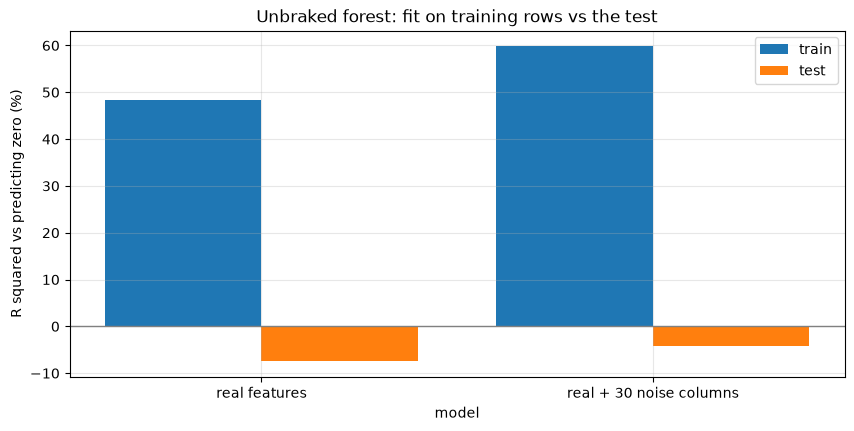

In [28]:
# The one slow demo: about 15 seconds (measured 11 to 16 s on 4 cores; Colab may take up to twice as long)
with timed("noise experiment"):
    noise = noise_experiment(train.sample(n=20000, random_state=0), test, n_noise=30, seed=0,
                             n_estimators=50, max_depth=None, min_samples_leaf=5)     # NO brakes, on purpose
noise.index = ["real features", "real + 30 noise columns"]
display(noise.map(pct).rename(columns={"train_r2": "R squared on training rows", "test_r2": "R squared on the test"}))
viz.train_vs_test_bars(noise, title="Unbraked forest: fit on training rows vs the test");

**Reading the result.** With the workshop's reference split we measured, on the real features, R squared +48% on
the training rows and -7.5% on the test. With 30 noise columns added: +60% on training and -4.1% on the test. The
unbraked forest "explains" half of the training data and then does **worse than predicting zero** on new data:
that gap is the signature of overfitting. Adding pure noise made the training score even better, which proves the
training score was measuring memory, not skill. (The test score moved a little too, but both are below zero:
neither model is usable.) The forest you chose in Task 4 has brakes: a depth limit, and leaves of at least 50
rows. That is why its training and test scores are much closer.

**Trying many things is the same problem.** Every time you change a setting and look at the test score again, you
are fitting the test period. Bailey and co-authors show how fast this goes wrong. With a two-year backtest, about
seven tries of strategies with no skill at all are enough to expect one with a **Sharpe ratio** around one. (The
Sharpe ratio is a strategy's average return divided by how much it swings, so higher is better; section 7 uses
it.) So count your tries, and touch the test period as few times as you can.

## 6. From forecasts to a portfolio

In [29]:
display(reading_box(["afml", "shumway_1997"],
    "Chapter 11: a backtest is only as honest as its trading rules and costs. Shumway: even a major research "
    "database was missing many returns of companies that left the market, so survivorship bias is a real problem."))

A forecast is not yet a trade. Each **rebalance** day we rank the 40 stocks by forecast and:

* go **long** the top `n_long`: buy them, and gain if their prices rise;
* go **short** the bottom `n_short`: borrow shares and sell them, and gain if their prices fall;
* give each stock on a side an **equal weight** (with 4 longs, 25% of the capital each), and hold nothing else.

The book is **dollar-neutral**: as much money long as short. So it does not bet on the whole market going up or
down, only on the top stocks beating the bottom ones. Only the **order** of the forecasts matters, not their size.
In section 7 we also draw the market: all 40 stocks bought in equal amounts and held. That line is **the market,
for scale**, not the benchmark to beat, because a dollar-neutral book is not trying to follow the market at all.

Every trade costs money. We charge **5 basis points** per unit traded: a **basis point** (bp) is one hundredth of
a percent, so 5 bps is 0.05%. **Turnover** is how much of the book changes at a rebalance; replacing every
position on both sides is a turnover of 4. Between rebalance days we hold the positions untouched.

In [30]:
panel = predict_panel(forest, test)                # forecasts: one row per test day, one column per stock
pred_today = panel.iloc[-1]                        # the forecasts on the last test day
ex.set_context(5, pred_today=pred_today)
ranked_today = pred_today.sort_values(ascending=False).map(pct).to_frame("forecast of the next 5-day return")
print(f"forecasts on {panel.index[-1].date()}: the four highest and the four lowest")
ranked_today.iloc[[0, 1, 2, 3, -4, -3, -2, -1]]

forecasts on 2019-12-20: the four highest and the four lowest


,forecast of the next 5-day return
CSCO,+1.61%
BA,+1.02%
WFC,+0.76%
XOM,+0.74%
TXN,+0.08%
INTC,+0.08%
C,+0.07%
WMT,+0.04%


Notice that even the lowest forecasts are usually above zero: the model predicts the market's slow upward drift for
nearly every stock. A long/short book does not care; it bets on the **ranking**, not the sign.

**Worked example: buy 4, short 4, rebalance every 5 trading days.**

In [31]:
n_long, n_short, rebalance_days = 4, 4, 5          # the worked example: buy 4, short 4, trade every 5 days
example_weights = weights_from_forecasts(pred_today, n_long=n_long, n_short=n_short)
example_weights[example_weights != 0].sort_values(ascending=False)

BA      0.25
CSCO    0.25
XOM     0.25
WFC     0.25
INTC   -0.25
C      -0.25
TXN    -0.25
WMT    -0.25
Name: weight, dtype: float64

### ✏️ Task 5: your portfolio
Copy and change: `n_long` and `n_short` from 1 to 8 each, and `rebalance_days` 5 (weekly), 10 (every two weeks) or
21 (about monthly). Fewer stocks means bigger bets on each; trading less often means lower costs but staler forecasts.

In [32]:
n_long, n_short, rebalance_days = 4, 4, 5          # <- change this: buy (1 to 8), short (1 to 8), days (5, 10 or 21)
my_weights = weights_from_forecasts(pred_today, n_long=n_long, n_short=n_short)
ex.check(5, my_weights, n_long, n_short, rebalance_days)

Task 5: Portfolio
  [x] Not yet: 4 long, 4 short, every 5 days is the worked example. Change at least one of the three numbers, for example rebalance_days = 21 (about monthly).
      Allowed: n_long and n_short from 1 to 8 each; rebalance_days 5, 10 or 21 (not all three of the worked example's).
      Help: ex.hint(5)   Answer: ex.show_solution(5)   Continue anyway: ex.use_reference(5)
  QSW_AUTO_REFERENCE=1: continuing with the reference answer (labelled).
  [ref] Task 5 (Portfolio): using the workshop REFERENCE answer. This is recorded, and labelled in your export.


**What do costs add up to?** In the workshop's backtests the turnover was about 3 to 3.2 per rebalance: most
positions change each time. At 5 bps that is about 0.16% of capital per rebalance.

🔮 **Predict:** roughly what share of your capital goes on costs in a year if you rebalance every week?

In [33]:
for days in (5, 10, 21):
    print(f"rebalance every {days:>2} trading days: costs of about {cost_per_year(3.2, days, 5):.1%} of capital a year")
print(f"\n{ex.knob_label('rebalance_days')}: every {my_strategy.rebalance_days} trading days")
ex.uses(5)                                         # a [ref] line if Task 5 is not yours yet

rebalance every  5 trading days: costs of about 8.1% of capital a year
rebalance every 10 trading days: costs of about 4.0% of capital a year
rebalance every 21 trading days: costs of about 1.9% of capital a year

the reference value: every 21 trading days
  [ref] Task 5 (Portfolio) is not yours yet: n_long = 4, n_short = 4, rebalance_days = 21 are the workshop's reference. Finish Task 5 above and run this cell again to use your own.


**Reading the result.** Trading weekly costs about 8% of capital a year; monthly about 2%. Compare that with the
edge from section 4: the best-ranked stocks beat the worst by about a tenth of a percent per 5 days. Costs are the
same size as the edge, so how often you trade can decide whether anything is left.

**Survivorship, the honest flaw.** All 40 companies survived to 2019. The ones that went bust or were taken over
are missing, and an investor in 2000 could not have known which would survive. Short positions suffer most: the
worst real outcomes, stocks that collapsed and disappeared, are exactly the ones a short book would have gained
on, and the ones a long book would have lost on. Either way, the backtest gets a hint from the future.

## 7. Your strategy's backtest

In [34]:
display(reading_box("arnott_2019",
    "a checklist for honest backtests: a reason before the data, a test period fixed in advance, every try "
    "counted, costs included, and suspicion of results that look too good."))

A **backtest** replays your rules over the test period, day by day, as if you had traded them: the forecasts,
the weights on each rebalance day, the costs, and the daily gains and losses. Four numbers summarise it:

* **total return**: how much 1 unit of capital grew or shrank over the whole test;
* **Sharpe ratio**: average daily return divided by how much it swings, scaled to a year. Higher is better;
  above 1 is rare for an honest strategy;
* **max drawdown**: the worst fall from a previous peak, the pain you would have sat through;
* **turnover**: how much of the book changed per rebalance (drives the costs).

First, your five knobs. Then the next cell rebuilds the features, the dataset and the split from those knobs,
exactly as sections 2 and 3 did. It fits your forest on the same quarter of the training rows as section 4. So a
task you went back and changed late is used here, and with unchanged knobs it is the same forest as section 4.
The cell takes about 3 s with the reference knobs, up to 10 s at 500 trees and depth 12; allow twice that on
Colab.

In [35]:
display(ex.knob_table())                           # 'yours' = set by you in a task; 'reference' = the workshop's answer
with timed("rebuild your data from your knobs and fit your forest"):
    final_feats = rank_normalise(build_features(prices, volume, names=my_strategy.feature_names))
    final_ds = make_dataset(final_feats, target)               # the same steps as section 2, with your final knobs
    final_train, final_test = time_split(final_ds, my_strategy.train_end, my_strategy.test_start)
    final_model = fit_forest(*xy(quarter_sample(final_train)), n_estimators=my_strategy.n_estimators,
                             max_depth=my_strategy.max_depth)   # the same quarter of the rows as section 4
panel = predict_panel(final_model, final_test)     # its forecasts for every test day and stock

,task,value,reference value,source
knob,,,,
momentum_lookback,1,21,21,reference
extra_feature,2,vol_63,vol_63,reference
train_end,3,2014-12-31,2014-12-31,reference
test_start,3,2015-01-12,2015-01-12,reference
n_estimators,4,200,200,reference
max_depth,4,6,6,reference
n_long,5,4,4,reference
n_short,5,4,4,reference
rebalance_days,5,21,21,reference


[time] rebuild your data from your knobs and fit your forest: 2.0 s


🔮 **Predict:** after costs, will your strategy make money over the test period? How much of its before-costs
return will the costs take?

,"your strategy, after costs","your strategy, before costs",the market (for scale)
total return,+6.4%,+17.2%,+86.3%
return per year,+1.3%,+3.3%,+13.4%
volatility per year,16.5%,16.5%,13.2%
Sharpe ratio,+0.16,+0.28,+1.02
max drawdown,-53.8%,-51.2%,-17.9%
turnover per rebalance,3.22,3.22,0.05
rebalances,60,60,60


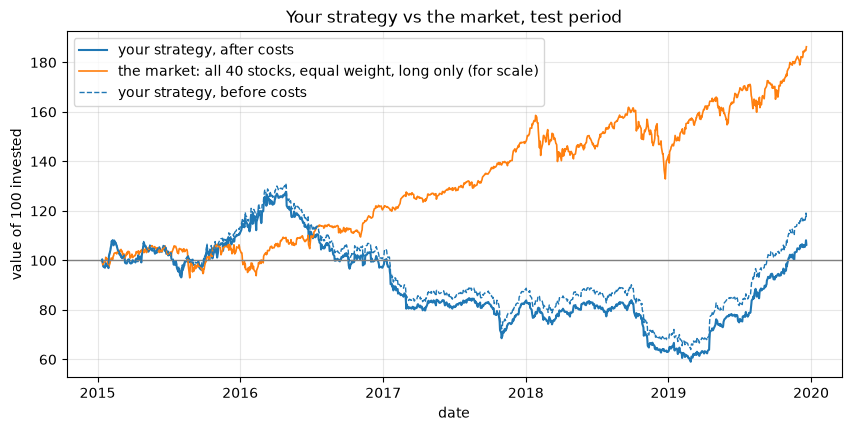

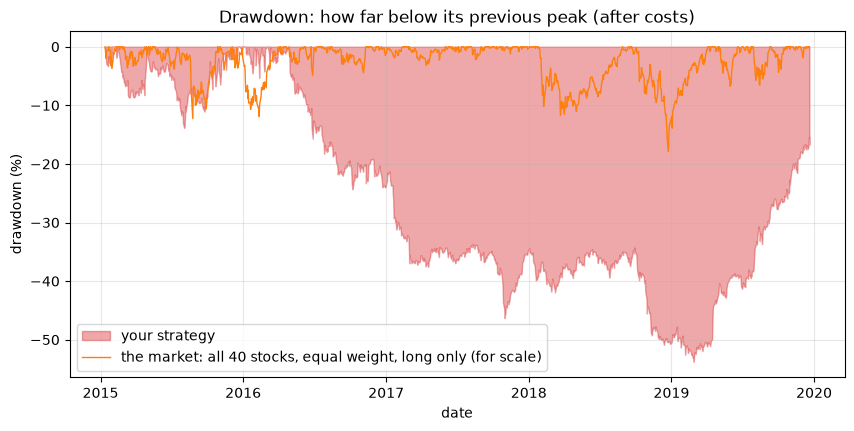

In [36]:
result = run_backtest(panel, returns, my_strategy)                               # your knobs, after 5 bps costs
before_costs = run_backtest(panel, returns, replace(my_strategy, cost_bps=0))    # the same trades, with no costs
market = run_benchmark(returns, panel.index, my_strategy)                        # all 40 stocks, equal weight, long only,
                                                                                 # rebalanced on the same days as yours
display(stats_view({"your strategy, after costs": result, "your strategy, before costs": before_costs,
                    "the market (for scale)": market}))
equity_figure(result, before_costs, market, title="Your strategy vs the market, test period");
drawdown_figure(result, market);

**One more run: the same forecasts, traded every 5 days.** This isolates what costs do: same model, same
frequency, with and without the 5 bps.

In [37]:
weekly = replace(my_strategy, rebalance_days=5)
stats_view({"every 5 days, before costs": run_backtest(panel, returns, replace(weekly, cost_bps=0)),
            "every 5 days, after costs": run_backtest(panel, returns, weekly)})

,"every 5 days, before costs","every 5 days, after costs"
total return,+22.9%,-15.8%
return per year,+4.3%,-3.4%
volatility per year,14.7%,14.8%
Sharpe ratio,+0.36,-0.16
max drawdown,-17.9%,-29.6%
turnover per rebalance,3.02,3.02
rebalances,250,250


**Reading the result, honestly.** With the reference knobs (rebalance every 21 days) we measured, from January 2015
to December 2019, +17.2% before costs and +6.4% after. The Sharpe ratio was 0.16 and the max drawdown -54%. Traded
every 5 days, the same forecasts made +22.9% before costs and **-15.8%** after. The costs ate everything, because the
edge is tiny and costs are the same size. Your numbers differ with your knobs. Do not expect them to look good,
and if they do, suspect them first.

The market line made about +86% (Sharpe 1.0), but it is **not** the benchmark to beat: it is long only, in a
rising, survivorship-biased market. The market line is rebalanced back to equal weights on the same days as your
strategy, so its numbers move slightly with your `rebalance_days`. A dollar-neutral long/short book does not try
to beat the market: its return is what the forecasts add on their own, and the market is shown for scale.

Five years cannot rank rebalance frequencies either. Fitted on all the training rows instead of a quarter
(`docs/core-results.md`), the same kind of forest's 10-day book lost about 35% before costs, while its 21-day
book made +16%. A different sample of training rows moved the before-costs result by more than any cost. So much
of the spread between frequencies is luck of the rows and the trading days, not a law about rebalancing.

**The Arnott, Harvey and Markowitz checklist, marked for this run:**

In [38]:
backtest_checklist(my_strategy, ex.any_reference, n_backtests_run=backtests_run())   # every backtest this session, counted

,this run,why
check,,
An economic reason before the data,✔ yes,the features come from published research: mom...
Test period chosen before seeing results,✔ yes,"you fixed 2015-01-12 onwards in Task 3, before..."
Every try counted and reported,✘ no,you have run 4 backtests in this session and t...
Data free of survivorship bias,✘ no,only companies that still trade in 2019 are in...
Trading costs included,✔ yes,5 bps per unit traded (but no borrowing fee fo...
Model kept simple,✔ yes,max_depth 6 with leaves of 50 rows
More than one test period,✘ no,one test window of about 5 years (from 2015-01...
Model refreshed as the world changes,✘ no,fitted once and never retrained during the test
"Own choices, not someone else's",✘ no,some knobs are still the reference


## 8. Export and paper trading

In [39]:
display(reading_box("deflated_sharpe_2014",
    "Part 2 next week: the deflated Sharpe ratio corrects a backtest's Sharpe ratio for the number of things you "
    "tried, plus purged cross-validation, triple-barrier labels and feature importance."))

**Export** saves your strategy as a folder that runs on its own, outside this notebook: your fitted model, your
knobs, the feature code, and `run_paper.py`, a small program that turns the latest prices into orders. The next
cell also zips the folder, checks the ZIP, and in Colab starts the download (about 1 s with the reference
knobs, up to 6 s at 500 trees and depth 12). **Download it now**: Colab forgets every file when the session
ends.

**Paper trading** means trading a practice account with pretend money. Alpaca offers free paper accounts. In this
room we only **preview**: the program proposes orders and submits nothing.

In [40]:
bundle_dir = WORK / "exports" / "my_strategy"
export_bundle(final_model, my_strategy, bundle_dir, used_reference=ex.any_reference,
              trained_on=final_train.attrs["features"])               # the features section 7 fitted on
zip_path = export_checkpoint(bundle_dir, WORK / "exports" / "my_strategy.zip")    # zip, check, and download in Colab

ZIP written: /Users/michaelbolebrukh/Downloads/quantsoc-ml-for-quant-finance/workspace/exports/my_strategy.zip (755 KB)
contents check: OK
Not running in Colab: the ZIP is saved in the folder shown above.


**The preview.** This runs `run_paper.py --preview` offline. It uses the saved price file instead of live prices,
and a **mock** broker (a pretend account with $100,000) instead of Alpaca. So it needs no account and no keys.

In [41]:
_ = run_paper_preview(ROOT, bundle_dir)            # python3 run_paper.py --preview --dry-data data/prices.csv.gz --bundle <your folder>

(in /Users/michaelbolebrukh/Downloads/quantsoc-ml-for-quant-finance)
$ python run_paper.py --preview --dry-data data/prices.csv.gz --bundle /Users/michaelbolebrukh/Downloads/quantsoc-ml-for-quant-finance/workspace/exports/my_strategy



  PREVIEW (OFFLINE DEMO): committed price snapshot and a mock broker, NO orders submitted
data: last 300 trading days of prices.csv.gz (offline, not live prices); mock broker starting with $100,000 and no positions
bundle my_strategy: Some knobs came from the workshop REFERENCE solution, not only your own work.
decision date 2019-12-30 (last completed trading day); forecasts are 5-day returns
long  (4): DIS +0.60%, GILD +0.67%, HD +0.68%, ORCL +0.64%
short (4): C +0.04%, JPM +0.05%, QCOM -0.02%, WFC +0.02%
equity $100,000.00; book sized on 50% of it = $50,000 long and $50,000 short (buying power $200,000)
proposed orders (8), reducing legs first; notional is an estimate at the last close:
symbol side qty notional current_qty target_qty     action
     C sell 198  $12,469           0       -198 open short
   DIS  buy  89  $12,406           0         89  open long
  GILD  buy 247  $12,495           0        247  open long
    HD  buy  67  $12,326           0         67  open long
   JPM 

**Reading the output.** The "long" list is the stocks with the highest forecasts. The "short" list is the
**lowest** forecasts, which are usually still slightly positive, because the model predicts the market's drift for
nearly every stock: a long/short book bets on the ranking, not the sign. An account's **equity** is its total
value, cash plus positions. The runner sizes the book on **50% of the account's equity** by default: half of it
long and half of it short. The last line says when your rebalance rule would trade next.

**Homework (optional).** Unzip your download and follow `README_EXPORT.md` inside it (the same file is
`docs/README_EXPORT.md` here). It shows how to run the preview on your own computer and, if you want, on a free
Alpaca paper account with live prices. It never touches real money. Part 2 next week fixes the problems we only
named today.

In [42]:
# INSTRUCTOR ONLY (leave False): writes the deck's four result figures to deck/figures/, always from the
# REFERENCE strategy, never your knobs. About 30 seconds.
SAVE_DECK_FIGURES = False
if SAVE_DECK_FIGURES:
    make_deck_figures(ROOT / "deck" / "figures", prices, volume, returns)

### Your strategy, in one table
`yours` means you set that knob in a task; `reference` means the workshop's answer is in use (your export records
which). Nothing in this notebook is investment advice.

**Part 2 next week:** purged cross-validation, triple-barrier labels, feature importance and the deflated Sharpe
ratio.

In [43]:
display(ex.knob_table())
ex.summary()

,task,value,reference value,source
knob,,,,
momentum_lookback,1,21,21,reference
extra_feature,2,vol_63,vol_63,reference
train_end,3,2014-12-31,2014-12-31,reference
test_start,3,2015-01-12,2015-01-12,reference
n_estimators,4,200,200,reference
max_depth,4,6,6,reference
n_long,5,4,4,reference
n_short,5,4,4,reference
rebalance_days,5,21,21,reference


,title,status,message
task,,,
1,Momentum lookback,reference,REFERENCE answer in use (not the participant's...
2,Extra feature,reference,REFERENCE answer in use (not the participant's...
3,Split dates,reference,REFERENCE answer in use (not the participant's...
4,Forest size,reference,REFERENCE answer in use (not the participant's...
5,Portfolio,reference,REFERENCE answer in use (not the participant's...
